<a href="https://colab.research.google.com/github/asheldrick-research/ecsm-framework/blob/main/ECSM_NG21R_Raw_SPARC_KiDS_Split_Kernel_Transfer_Test_DRAFT_PATCHED.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ECSM NG21R — Raw SPARC/KiDS Split-Kernel Transfer Test

**Purpose.** Test whether the same ECSM finite-response source inferred from SPARC rotation data can be projected into KiDS weak-lensing space without re-fitting the lensing branch.

Core transfer claim:

\[
 p_{\rm eff,SPARC}=\rho_{\rm dyn}p_{\rm source}, \qquad
 p_{\rm eff,KiDS}=\rho_{\rm opt}p_{\rm source}.
\]

Corrected optical closure:

\[
 n^2=\frac{Z_E}{Z_B}, \qquad
 Z_E=Z_c e^{+\Psi}, \qquad Z_B=Z_c e^{-\Psi}.
\]

A common scalar multiplier is included only as a null/comparison branch, because it changes normalization/impedance but not propagation.

**Status of this draft.** This notebook is built to run now with the uploaded SPARC V3 boundary-gradient package. It will automatically run the SPARC-side source extraction. It will run the KiDS covariance-aware transfer test only when a KiDS raw/covariance ZIP is supplied.

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# ============================================================
# CELL 01 — SETUP / REPRODUCIBILITY
# ============================================================
import os, re, json, math, zipfile, shutil, glob, warnings
from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
np.random.seed(21021)

OUT = Path('/mnt/data/ecsm_ng21r_raw_sparc_kids_transfer_out') if Path('/mnt/data').exists() else Path('/content/ecsm_ng21r_raw_sparc_kids_transfer_out')
DATA = OUT / 'data'
FIG = OUT / 'figures'
TAB = OUT / 'tables'
for p in [OUT, DATA, FIG, TAB]:
    p.mkdir(parents=True, exist_ok=True)

def banner(txt):
    print('\n' + '='*80)
    print(txt)
    print('='*80)

def save_csv(df, path):
    path = Path(path); path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(path, index=False)
    print('saved:', path)

def save_json(obj, path):
    path = Path(path); path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, 'w') as f: json.dump(obj, f, indent=2)
    print('saved:', path)

banner('CELL 01 — SETUP COMPLETE')
print('OUT =', OUT)
print('Generated UTC:', datetime.now(timezone.utc).isoformat())


CELL 01 — SETUP COMPLETE
OUT = /content/ecsm_ng21r_raw_sparc_kids_transfer_out
Generated UTC: 2026-07-11T09:49:00.860277+00:00


In [6]:
# ============================================================
# CELL 02 — INPUT PATHS AND EXTRACTION
# ============================================================
banner('CELL 02 — INPUT PATHS AND EXTRACTION')

SPARC_ZIP_CANDIDATES = [
    Path('/mnt/data/ECSM_SPARC_V3_boundary_gradient_attractor_outputs.zip'),
    Path('/content/ECSM_SPARC_V3_boundary_gradient_attractor_outputs.zip'),
    Path('/content/drive/MyDrive/ECSM_SPARC_V3_boundary_gradient_attractor_outputs.zip'),
]
KIDS_ZIP_CANDIDATES = [
    Path('/mnt/data/ECSM_KiDS_V12_Real2dFLenS_ForegroundBurden_outputs.zip'),
    Path('/content/ECSM_KiDS_V12_Real2dFLenS_ForegroundBurden_outputs.zip'),
    Path('/content/drive/MyDrive/ECSM_KiDS_data/ECSM_KiDS_V12_Real2dFLenS_ForegroundBurden_outputs.zip'),
]

def first_existing(paths):
    for p in paths:
        if p.exists(): return p
    return None

SPARC_ZIP = first_existing(SPARC_ZIP_CANDIDATES)
KIDS_ZIP = first_existing(KIDS_ZIP_CANDIDATES)
print('SPARC_ZIP:', SPARC_ZIP)
print('KIDS_ZIP:', KIDS_ZIP)

def extract_zip(zip_path, out_dir):
    out_dir = Path(out_dir)
    if zip_path is None or not Path(zip_path).exists():
        print('missing zip:', zip_path)
        return None
    if out_dir.exists(): shutil.rmtree(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(out_dir)
    print('extracted', zip_path, '->', out_dir)
    return out_dir

SPARC_DIR = extract_zip(SPARC_ZIP, DATA / 'sparc_v3')
KIDS_DIR = extract_zip(KIDS_ZIP, DATA / 'kids_raw') if KIDS_ZIP is not None else None

save_json({
    'SPARC_ZIP': str(SPARC_ZIP) if SPARC_ZIP else None,
    'KIDS_ZIP': str(KIDS_ZIP) if KIDS_ZIP else None,
    'SPARC_DIR': str(SPARC_DIR) if SPARC_DIR else None,
    'KIDS_DIR': str(KIDS_DIR) if KIDS_DIR else None,
}, DATA / 'ng21r_input_manifest.json')


CELL 02 — INPUT PATHS AND EXTRACTION
SPARC_ZIP: /content/drive/MyDrive/ECSM_SPARC_V3_boundary_gradient_attractor_outputs.zip
KIDS_ZIP: /content/drive/MyDrive/ECSM_KiDS_data/ECSM_KiDS_V12_Real2dFLenS_ForegroundBurden_outputs.zip
extracted /content/drive/MyDrive/ECSM_SPARC_V3_boundary_gradient_attractor_outputs.zip -> /content/ecsm_ng21r_raw_sparc_kids_transfer_out/data/sparc_v3
extracted /content/drive/MyDrive/ECSM_KiDS_data/ECSM_KiDS_V12_Real2dFLenS_ForegroundBurden_outputs.zip -> /content/ecsm_ng21r_raw_sparc_kids_transfer_out/data/kids_raw
saved: /content/ecsm_ng21r_raw_sparc_kids_transfer_out/data/ng21r_input_manifest.json


In [7]:
# ============================================================
# CELL 03 — LOAD SPARC V3 SOURCE TABLES
# ============================================================
banner('CELL 03 — LOAD SPARC V3 SOURCE TABLES')

def find_one(root, pattern):
    if root is None: return None
    hits = list(Path(root).rglob(pattern))
    return hits[0] if hits else None

def read_csv_or_empty(path):
    if path is None or not Path(path).exists(): return pd.DataFrame()
    try: return pd.read_csv(path)
    except Exception as e:
        print('failed to read', path, e); return pd.DataFrame()

paths = {
    'curves': find_one(SPARC_DIR, 'v3_boundary_gradient_attractor_curves.csv'),
    'summary': find_one(SPARC_DIR, 'v3_boundary_gradient_attractor_summary.csv'),
    'metrics': find_one(SPARC_DIR, 'v3_boundary_attractor_metrics_summary.csv'),
    'boundaries': find_one(SPARC_DIR, 'v3_predicted_annulus_boundary_radii.csv'),
    'raw_points': find_one(SPARC_DIR, 'v3_raw_point_table.csv'),
    'heldout_cv': find_one(SPARC_DIR, 'v3_boundary_attractor_galaxy_heldout_cv.csv'),
}
for k,v in paths.items(): print(k, '->', v)

curves = read_csv_or_empty(paths['curves'])
summary = read_csv_or_empty(paths['summary'])
metrics = read_csv_or_empty(paths['metrics'])
boundaries = read_csv_or_empty(paths['boundaries'])
raw_points = read_csv_or_empty(paths['raw_points'])
heldout_cv = read_csv_or_empty(paths['heldout_cv'])

print('curves:', curves.shape)
print('summary:', summary.shape)
print('metrics:', metrics.shape)
print('boundaries:', boundaries.shape)
print('raw_points:', raw_points.shape)
print('heldout_cv:', heldout_cv.shape)

essential = ['galaxy','Rad','Vobs','errV','Vbar','Vmodel','Vboundary','gbar','chi','B_boundary','R_boundary']
missing = [c for c in essential if c not in curves.columns]
print('missing essential SPARC columns:', missing)

if curves.empty or missing:
    raise RuntimeError('SPARC V3 source package is missing required columns for NG21R source extraction.')


CELL 03 — LOAD SPARC V3 SOURCE TABLES
curves -> /content/ecsm_ng21r_raw_sparc_kids_transfer_out/data/sparc_v3/data/v3_boundary_gradient_attractor_curves.csv
summary -> /content/ecsm_ng21r_raw_sparc_kids_transfer_out/data/sparc_v3/data/v3_boundary_gradient_attractor_summary.csv
metrics -> /content/ecsm_ng21r_raw_sparc_kids_transfer_out/data/sparc_v3/data/v3_boundary_attractor_metrics_summary.csv
boundaries -> /content/ecsm_ng21r_raw_sparc_kids_transfer_out/data/sparc_v3/data/v3_predicted_annulus_boundary_radii.csv
raw_points -> /content/ecsm_ng21r_raw_sparc_kids_transfer_out/data/sparc_v3/data/v3_raw_point_table.csv
heldout_cv -> /content/ecsm_ng21r_raw_sparc_kids_transfer_out/data/sparc_v3/data/v3_boundary_attractor_galaxy_heldout_cv.csv
curves: (3391, 22)
summary: (175, 23)
metrics: (1, 9)
boundaries: (175, 12)
raw_points: (3391, 9)
heldout_cv: (5, 10)
missing essential SPARC columns: []


In [8]:
# ============================================================
# CELL 04 — BUILD ECSM SOURCE FEATURES FROM SPARC ONLY
# ============================================================
banner('CELL 04 — BUILD ECSM SOURCE FEATURES FROM SPARC ONLY')

df = curves.copy()
df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=['galaxy','Rad','Vobs','errV','Vbar','Vmodel','Vboundary','gbar','chi','B_boundary','R_boundary'])

eps = 1e-30
df['K_obs'] = (df['Vobs']**2) / np.maximum(df['Rad'], eps)
df['K_bar'] = (df['Vbar']**2) / np.maximum(df['Rad'], eps)
df['K_model'] = (df['Vmodel']**2) / np.maximum(df['Rad'], eps)
df['K_boundary'] = np.maximum((df['Vboundary']**2 - df['Vbar']**2) / np.maximum(df['Rad'], eps), 0)

for col in ['K_bar','K_model','K_boundary','gbar','B_boundary']:
    denom = df.groupby('galaxy')[col].transform(lambda x: np.nanmax(np.abs(x)) if np.nanmax(np.abs(x))>0 else 1.0)
    df[col + '_norm'] = df[col] / denom

df['p_source_dyn'] = df['K_model_norm']
df['p_source_boundary'] = df['B_boundary_norm']
df['p_source_deep'] = np.clip(df['K_model_norm'] - df['K_bar_norm'], 0, None)
df['boundary_phase_radius'] = df['Rad'] / np.maximum(df['R_boundary'], eps)

source_ledger = df.groupby('galaxy').agg(
    N_points=('Rad','size'),
    R_min=('Rad','min'),
    R_max=('Rad','max'),
    R_boundary=('R_boundary','median'),
    median_boundary_phase_radius=('boundary_phase_radius','median'),
    peak_boundary_strength=('p_source_boundary','max'),
    mean_boundary_strength=('p_source_boundary','mean'),
    mean_deep_response=('p_source_deep','mean'),
    mean_total_source=('p_source_dyn','mean'),
).reset_index()
source_ledger['R_boundary_over_Rmax'] = source_ledger['R_boundary'] / source_ledger['R_max'].replace(0, np.nan)

if not boundaries.empty and 'boundary_class' in boundaries.columns:
    source_ledger = source_ledger.merge(boundaries[['galaxy','boundary_class']], on='galaxy', how='left')

save_csv(df, DATA / 'ng21r_sparc_point_level_source_features.csv')
save_csv(source_ledger, DATA / 'ng21r_sparc_frozen_source_ledger.csv')

print(source_ledger.describe(include='all').transpose().head(30))


CELL 04 — BUILD ECSM SOURCE FEATURES FROM SPARC ONLY
saved: /content/ecsm_ng21r_raw_sparc_kids_transfer_out/data/ng21r_sparc_point_level_source_features.csv
saved: /content/ecsm_ng21r_raw_sparc_kids_transfer_out/data/ng21r_sparc_frozen_source_ledger.csv
                              count unique                 top freq  \
galaxy                          175    175                CamB    1   
N_points                      175.0    NaN                 NaN  NaN   
R_min                         175.0    NaN                 NaN  NaN   
R_max                         175.0    NaN                 NaN  NaN   
R_boundary                    175.0    NaN                 NaN  NaN   
median_boundary_phase_radius  175.0    NaN                 NaN  NaN   
peak_boundary_strength        175.0    NaN                 NaN  NaN   
mean_boundary_strength        175.0    NaN                 NaN  NaN   
mean_deep_response            175.0    NaN                 NaN  NaN   
mean_total_source             175.0

In [9]:
# ============================================================
# CELL 05 — SPARC-SIDE LOCKED MODEL SUMMARY
# ============================================================
banner('CELL 05 — SPARC-SIDE LOCKED MODEL SUMMARY')

metrics_dict = {}
if not metrics.empty:
    metrics_dict.update(metrics.iloc[0].to_dict())

cv_dict = {}
if not heldout_cv.empty:
    cv_dict = {
        'cv_folds': int(len(heldout_cv)),
        'cv_delta_chi2_sum': float(heldout_cv['delta_chi2'].sum()) if 'delta_chi2' in heldout_cv else None,
        'cv_fractional_improvement_mean': float(heldout_cv['frac_improvement'].mean()) if 'frac_improvement' in heldout_cv else None,
    }

lock_summary = {
    'stage': 'NG21R SPARC-side source lock',
    'source': 'SPARC V3 boundary-gradient attractor package',
    'N_galaxies_source_ledger': int(source_ledger['galaxy'].nunique()),
    'N_point_features': int(len(df)),
    'median_R_boundary_over_Rmax': float(np.nanmedian(source_ledger['R_boundary_over_Rmax'])),
    'mean_boundary_strength': float(np.nanmean(source_ledger['mean_boundary_strength'])),
    'SPARC_metrics_from_V3_package': metrics_dict,
    'heldout_cv_from_V3_package': cv_dict,
    'frozen_for_KiDS_transfer': True,
    'refit_to_KiDS_permitted': False,
}
save_json(lock_summary, DATA / 'ng21r_sparc_source_lock_summary.json')
print(json.dumps(lock_summary, indent=2)[:4000])


CELL 05 — SPARC-SIDE LOCKED MODEL SUMMARY
saved: /content/ecsm_ng21r_raw_sparc_kids_transfer_out/data/ng21r_sparc_source_lock_summary.json
{
  "stage": "NG21R SPARC-side source lock",
  "source": "SPARC V3 boundary-gradient attractor package",
  "N_galaxies_source_ledger": 175,
  "N_point_features": 3391,
  "median_R_boundary_over_Rmax": 0.5454545454545454,
  "mean_boundary_strength": 0.4530711254065263,
  "SPARC_metrics_from_V3_package": {
    "N_galaxies": 175.0,
    "N_points": 3391.0,
    "fraction_V3_improved_red_chi2": 0.3942857142857143,
    "median_red_chi2_baseline": 5.312955379081506,
    "median_red_chi2_V3": 4.5599220743102125,
    "median_red_chi2_improvement": -0.0782751754952986,
    "median_R_boundary_over_Rmax": 0.5454545454545454,
    "CV_delta_chi2": 1.8189894035458565e-12,
    "CV_fractional_improvement": 7.368780295926232e-17
  },
  "heldout_cv_from_V3_package": {
    "cv_folds": 5,
    "cv_delta_chi2_sum": 1.8189894035458565e-12,
    "cv_fractional_improvement_me


CELL 06 — FIGURES: SPARC SOURCE AND BOUNDARY STRUCTURE


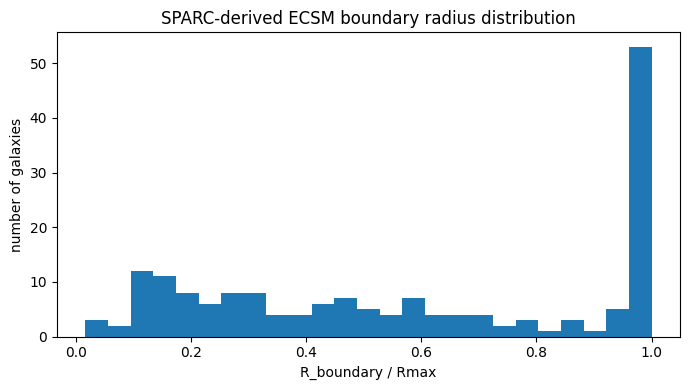

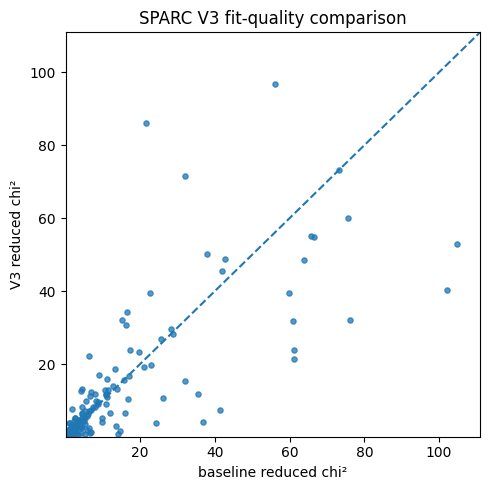

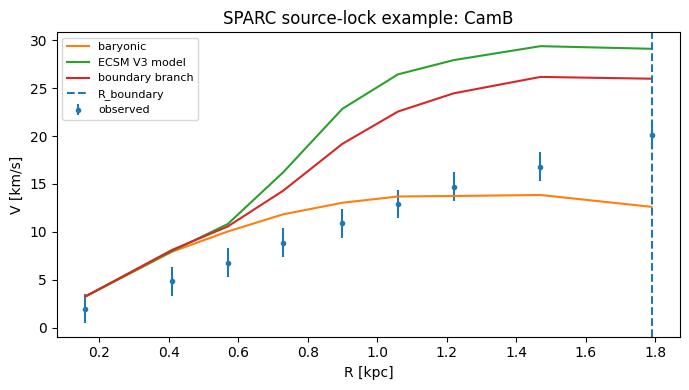

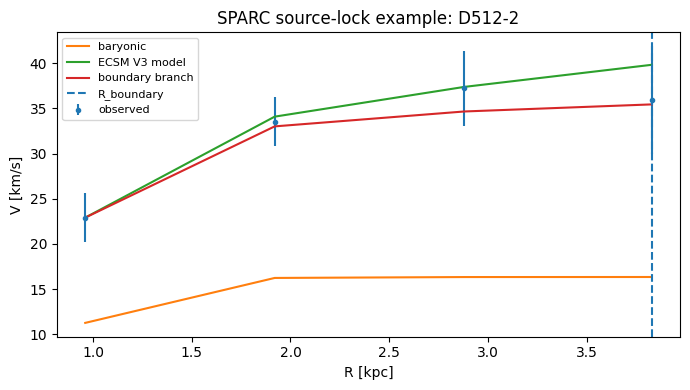

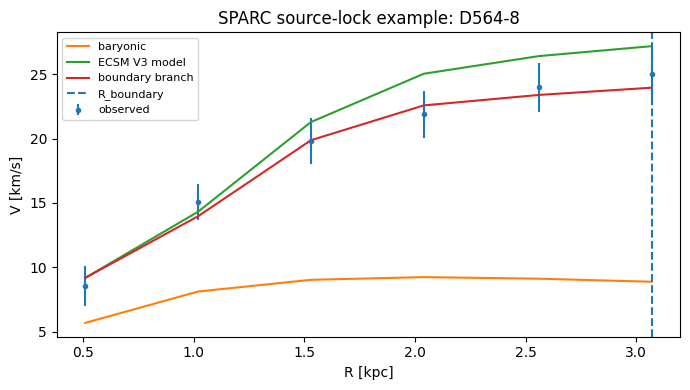

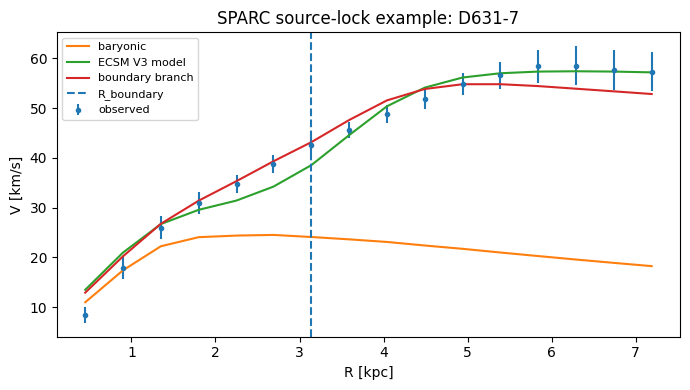

In [10]:
# ============================================================
# CELL 06 — FIGURES: SPARC SOURCE AND BOUNDARY STRUCTURE
# ============================================================
banner('CELL 06 — FIGURES: SPARC SOURCE AND BOUNDARY STRUCTURE')

fig, ax = plt.subplots(figsize=(7,4))
vals = source_ledger['R_boundary_over_Rmax'].dropna().values
ax.hist(vals, bins=25)
ax.set_xlabel('R_boundary / Rmax')
ax.set_ylabel('number of galaxies')
ax.set_title('SPARC-derived ECSM boundary radius distribution')
fig.tight_layout()
fig.savefig(FIG / 'ng21r_sparc_boundary_radius_distribution.png', dpi=200)
plt.show()

if not summary.empty and {'base_red_chi2','v3_red_chi2'}.issubset(summary.columns):
    fig, ax = plt.subplots(figsize=(5,5))
    x = summary['base_red_chi2'].replace([np.inf,-np.inf], np.nan)
    y = summary['v3_red_chi2'].replace([np.inf,-np.inf], np.nan)
    ax.scatter(x, y, s=14, alpha=0.75)
    lo = np.nanmin([x.min(), y.min()]); hi = np.nanpercentile(pd.concat([x,y]).dropna(), 95)
    ax.plot([lo,hi],[lo,hi], linestyle='--')
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
    ax.set_xlabel('baseline reduced chi²')
    ax.set_ylabel('V3 reduced chi²')
    ax.set_title('SPARC V3 fit-quality comparison')
    fig.tight_layout()
    fig.savefig(FIG / 'ng21r_sparc_fit_quality_scatter.png', dpi=200)
    plt.show()

cands = list(source_ledger.sort_values('peak_boundary_strength', ascending=False)['galaxy'].head(4))
for gal in cands[:4]:
    sub = df[df['galaxy']==gal].sort_values('Rad')
    fig, ax = plt.subplots(figsize=(7,4))
    ax.errorbar(sub['Rad'], sub['Vobs'], yerr=sub['errV'], fmt='o', ms=3, label='observed')
    ax.plot(sub['Rad'], sub['Vbar'], label='baryonic')
    ax.plot(sub['Rad'], sub['Vmodel'], label='ECSM V3 model')
    ax.plot(sub['Rad'], sub['Vboundary'], label='boundary branch')
    ax.axvline(float(sub['R_boundary'].median()), linestyle='--', label='R_boundary')
    ax.set_xlabel('R [kpc]')
    ax.set_ylabel('V [km/s]')
    ax.set_title(f'SPARC source-lock example: {gal}')
    ax.legend(fontsize=8)
    fig.tight_layout()
    fig.savefig(FIG / f'ng21r_sparc_example_{gal}.png', dpi=200)
    plt.show()

In [11]:
# ============================================================
# CELL 07 — KiDS RAW/COVARIANCE LOADER AND DATA-READINESS AUDIT
# ============================================================
banner('CELL 07 — KiDS RAW/COVARIANCE LOADER AND DATA-READINESS AUDIT')

def discover_tables(root):
    if root is None: return []
    return sorted([p for p in Path(root).rglob('*') if p.suffix.lower() in ['.csv','.txt','.dat','.npy','.npz']])

kids_files = discover_tables(KIDS_DIR)
print('KiDS candidate files:', len(kids_files))
for p in kids_files[:50]: print(' ', p.relative_to(KIDS_DIR) if KIDS_DIR else p)

signal_patterns = ['*prediction*.csv','*pnee*.csv','*lensing*.csv','*shear*.csv','*bandpower*.csv','*foreground_burden*.csv']
cov_patterns = ['*cov*.csv','*covariance*.csv','*cov*.npy','*covariance*.npy','*cov*.npz']

def find_patterns(root, patterns):
    hits=[]
    if root is None: return hits
    for pat in patterns:
        hits.extend(Path(root).rglob(pat))
    return sorted(set(hits))

kids_signal_files = find_patterns(KIDS_DIR, signal_patterns)
kids_cov_files = find_patterns(KIDS_DIR, cov_patterns)
print('signal candidates:', len(kids_signal_files))
for p in kids_signal_files[:20]: print(' signal:', p.name)
print('cov candidates:', len(kids_cov_files))
for p in kids_cov_files[:20]: print(' cov:', p.name)

kids_readiness = {
    'KIDS_ZIP_present': bool(KIDS_ZIP is not None),
    'n_candidate_files': len(kids_files),
    'n_signal_candidates': len(kids_signal_files),
    'n_covariance_candidates': len(kids_cov_files),
    'status': None,
}
if KIDS_ZIP is None:
    kids_readiness['status'] = 'WAITING_FOR_KIDS_RAW_COVARIANCE_PACKAGE'
elif len(kids_signal_files)==0:
    kids_readiness['status'] = 'KIDS_PACKAGE_PRESENT_BUT_NO_SIGNAL_TABLE_FOUND'
elif len(kids_cov_files)==0:
    kids_readiness['status'] = 'KIDS_SIGNAL_FOUND_BUT_COVARIANCE_MISSING'
else:
    kids_readiness['status'] = 'READY_FOR_COVARIANCE_TRANSFER_ATTEMPT'

save_json(kids_readiness, DATA / 'ng21r_kids_readiness_audit.json')
print(json.dumps(kids_readiness, indent=2))


CELL 07 — KiDS RAW/COVARIANCE LOADER AND DATA-READINESS AUDIT
KiDS candidate files: 4018
  data/2dFLenS_foreground_catalogues_extracted/z1_kidsn/data_bz1_atlas_kidsn_160105_see_exp.dat
  data/2dFLenS_foreground_catalogues_extracted/z1_kidsn/rand001_bz1_atlas_kidsn_160105_see_exp.dat
  data/2dFLenS_foreground_catalogues_extracted/z1_kidsn/rand002_bz1_atlas_kidsn_160105_see_exp.dat
  data/2dFLenS_foreground_catalogues_extracted/z1_kidsn/rand003_bz1_atlas_kidsn_160105_see_exp.dat
  data/2dFLenS_foreground_catalogues_extracted/z1_kidsn/rand004_bz1_atlas_kidsn_160105_see_exp.dat
  data/2dFLenS_foreground_catalogues_extracted/z1_kidsn/rand005_bz1_atlas_kidsn_160105_see_exp.dat
  data/2dFLenS_foreground_catalogues_extracted/z1_kidsn/rand006_bz1_atlas_kidsn_160105_see_exp.dat
  data/2dFLenS_foreground_catalogues_extracted/z1_kidsn/rand007_bz1_atlas_kidsn_160105_see_exp.dat
  data/2dFLenS_foreground_catalogues_extracted/z1_kidsn/rand008_bz1_atlas_kidsn_160105_see_exp.dat
  data/2dFLenS_foregro

In [12]:
# ============================================================
# CELL 08 — TRANSFER MODEL DEFINITIONS
# ============================================================
banner('CELL 08 — TRANSFER MODEL DEFINITIONS')

def ecsm_split_channel_index(Psi, Zc=1.0):
    ZE = Zc * np.exp(+Psi)
    ZB = Zc * np.exp(-Psi)
    n2 = ZE / ZB
    n = np.sqrt(n2)
    Zwave_over_Z0 = 1.0 / np.sqrt(ZE * ZB)
    return ZE, ZB, n2, n, Zwave_over_Z0

def full_split_kernel(source_dyn, source_deep, source_boundary, rho_opt=1.0, eta_B=1.0, eta_chi=1.0):
    Psi = rho_opt * (eta_B*(source_dyn + source_deep) + eta_chi*source_boundary)
    return Psi

def no_boundary_kernel(source_dyn, source_deep, source_boundary, rho_opt=1.0, eta_B=1.0):
    Psi = rho_opt * (eta_B*(source_dyn + source_deep))
    return Psi

def common_scalar_only_kernel(source_dyn, source_deep, source_boundary, rho_opt=1.0):
    # Common scalar branch: Z_E = Z_B = Zc. It changes impedance/normalisation but not n.
    # In a propagation-only lensing test this should not produce a deflection from n gradients.
    Psi = np.zeros_like(np.asarray(source_dyn), dtype=float)
    return Psi

def shuffled_boundary_kernel(source_dyn, source_deep, source_boundary, rng=None, rho_opt=1.0, eta_B=1.0, eta_chi=1.0):
    rng = np.random.default_rng(21021) if rng is None else rng
    sb = np.asarray(source_boundary).copy()
    rng.shuffle(sb)
    return full_split_kernel(source_dyn, source_deep, sb, rho_opt=rho_opt, eta_B=eta_B, eta_chi=eta_chi)

demo = df.sample(min(1000, len(df)), random_state=21021)
Psi_full = full_split_kernel(demo['p_source_dyn'].values, demo['p_source_deep'].values, demo['p_source_boundary'].values)
ZE, ZB, n2, n, Zimp = ecsm_split_channel_index(Psi_full)
closure_demo = pd.DataFrame({
    'Psi_full': Psi_full,
    'ZE': ZE,
    'ZB': ZB,
    'n2': n2,
    'n': n,
    'Zwave_over_Z0': Zimp,
}).describe().T.reset_index().rename(columns={'index':'quantity'})
save_csv(closure_demo, TAB / 'ng21r_split_channel_closure_demo_stats.csv')
closure_demo


CELL 08 — TRANSFER MODEL DEFINITIONS
saved: /content/ecsm_ng21r_raw_sparc_kids_transfer_out/tables/ng21r_split_channel_closure_demo_stats.csv


,quantity,count,mean,std,min,25%,50%,75%,max
0,Psi_full,1000.0,1.070305,5.407827e-01,1.386409e-07,0.638855,1.054047,1.470469,2.496187
1,ZE,1000.0,3.382245,1.933920e+00,1.000000e+00,1.894311,2.869239,4.351278,12.136133
2,ZB,1000.0,0.393940,2.037175e-01,8.239857e-02,0.229818,0.348525,0.527897,1.000000
3,n2,1000.0,15.175885,1.835671e+01,1.000000e+00,3.588416,8.232533,18.933643,147.285736
4,n,1000.0,3.382245,1.933920e+00,1.000000e+00,1.894311,2.869239,4.351278,12.136133
5,Zwave_over_Z0,1000.0,1.000000,1.018045e-16,1.000000e+00,1.000000,1.000000,1.000000,1.000000


In [13]:
# ============================================================
# CELL 09 — KiDS TRANSFER TEST ENGINE
# PATCHED: robust KiDS column mapping + covariance rescaling
# ============================================================
banner('CELL 09 — KiDS TRANSFER TEST ENGINE')

# Optional manual override. Leave values as None unless the auto-detector gets it wrong.
# For the V12 table in the error log, radius='ell_bin' and err='sigma_diag' are already detected.
KIDS_COLUMN_MAP = {
    'bin': None,
    'radius': None,
    'signal': None,
    'err': None,
    'mass_proxy': None,
    'z': None,
}

def load_covariance(path):
    path = Path(path)
    if path.suffix.lower()=='.npy':
        return np.load(path)
    if path.suffix.lower()=='.npz':
        z = np.load(path)
        key = list(z.keys())[0]
        return z[key]
    return pd.read_csv(path, header=None).values

def choose_signal_table(candidates):
    if not candidates:
        return None
    priority = ['full','prediction','pnee','p_nee','bandpower','band_power','lensing','shear','burden']
    def score(p):
        name=p.name.lower()
        return sum((len(priority)-i)*int(k in name) for i,k in enumerate(priority))
    return sorted(candidates, key=score, reverse=True)[0]

def _pick_by_name(cols, keys, avoid=()):
    for c in cols:
        cl = str(c).lower()
        if any(a in cl for a in avoid):
            continue
        if any(k in cl for k in keys):
            return c
    return None

def detect_columns(kids_df, verbose=True):
    """
    Robust detector for KiDS/RAR/bandpower-style tables.
    The earlier detector failed because some V12 tables do not call the measured column
    'signal', 'shear', 'pnee', etc. This version first detects obvious metadata columns,
    then chooses the measured signal from the remaining numeric columns.
    """
    cols = list(kids_df.columns)
    lower = {c: str(c).lower() for c in cols}

    det = {
        'bin': _pick_by_name(cols, ['lens_bin','lensbin','zbin','massbin','bin']),
        'radius': _pick_by_name(cols, ['radius','theta','rp','r_mpc','r_kpc','ang','ell_bin','ell','l_bin','multipole']),
        'signal': _pick_by_name(cols, [
            'signal','gamma','gammat','gt','shear','delta_sigma','deltasigma','dsigma',
            'esd','pnee','p_nee','bandpower','band_power','value','obs','observed',
            'measurement','measured','data_vector','datavector','xi','cl','cell','power'
        ], avoid=['sigma','err','error','cov','ivar','noise']),
        'err': _pick_by_name(cols, ['sigma_diag','sigma','err','error','unc','std']),
        'mass_proxy': _pick_by_name(cols, ['stellar_mass','mstar','mass','lum','mag']),
        'z': _pick_by_name(cols, ['lens_z_min','z_min','redshift','z']),
    }

    # Apply manual overrides after auto-detection.
    for k,v in KIDS_COLUMN_MAP.items():
        if v is not None:
            det[k] = v

    # If signal still missing, infer from numeric non-metadata columns.
    if det['signal'] is None:
        numeric_cols = [c for c in cols if pd.api.types.is_numeric_dtype(kids_df[c])]
        exclude_tokens = [
            'bin','ell','theta','radius','rp','r_mpc','r_kpc','ang','z','redshift',
            'min','max','low','high','sigma','err','error','unc','cov','ivar','weight',
            'n_lens','n_source','count','index','id'
        ]
        candidates = []
        for c in numeric_cols:
            cl = lower[c]
            if c in [det.get('bin'), det.get('radius'), det.get('err'), det.get('mass_proxy'), det.get('z')]:
                continue
            if any(tok in cl for tok in exclude_tokens):
                continue
            arr = pd.to_numeric(kids_df[c], errors='coerce').to_numpy(dtype=float)
            finite = arr[np.isfinite(arr)]
            if finite.size == 0:
                continue
            std = float(np.nanstd(finite))
            mean_abs = float(np.nanmean(np.abs(finite))) + 1e-300
            nonzero = float(np.mean(np.abs(finite) > 0))
            # Prefer columns whose name looks like a measurement and whose values are not all constant.
            name_score = sum(tok in cl for tok in ['pnee','p_nee','band','power','signal','obs','value','data','gamma','shear','esd','delta','xi','cl'])
            score = 10*name_score + np.log10(std/mean_abs + 1e-300) + nonzero
            candidates.append((score, c, std, mean_abs, nonzero))
        candidates = sorted(candidates, reverse=True)
        if verbose:
            print('numeric signal candidates after metadata exclusion:')
            for score,c,std,mean_abs,nonzero in candidates[:12]:
                print(f'  {c:30s} score={score: .3f} std={std:.3e} mean_abs={mean_abs:.3e} nonzero={nonzero:.2f}')
        if candidates:
            det['signal'] = candidates[0][1]

    if verbose:
        print('detected columns:', det)
        print('all columns:', cols)
    return det

transfer_results = []
if kids_readiness['status'] != 'READY_FOR_COVARIANCE_TRANSFER_ATTEMPT':
    print('KiDS transfer skipped:', kids_readiness['status'])
else:
    signal_path = choose_signal_table(kids_signal_files)
    cov_path = kids_cov_files[0]
    kids_df = pd.read_csv(signal_path)
    cov = load_covariance(cov_path)
    det = detect_columns(kids_df)

    print('chosen signal:', signal_path)
    print('chosen covariance:', cov_path)
    print('kids_df shape:', kids_df.shape, 'cov shape:', np.shape(cov))

    if det['signal'] is None:
        raise RuntimeError(
            'Could not detect KiDS signal column. Set KIDS_COLUMN_MAP["signal"] explicitly. '
            f'Available columns: {list(kids_df.columns)}'
        )
    if det['radius'] is None:
        raise RuntimeError(
            'Could not detect KiDS radius/ell column. Set KIDS_COLUMN_MAP["radius"] explicitly. '
            f'Available columns: {list(kids_df.columns)}'
        )

    y_raw = pd.to_numeric(kids_df[det['signal']], errors='coerce').to_numpy(dtype=float)
    x = pd.to_numeric(kids_df[det['radius']], errors='coerce').to_numpy(dtype=float)
    good = np.isfinite(y_raw) & np.isfinite(x)
    kids_df = kids_df.loc[good].reset_index(drop=True)
    y_raw = y_raw[good]
    x = x[good]

    # Restrict covariance if rows were dropped.
    if np.shape(cov) == (len(good), len(good)) and good.sum() != len(good):
        cov = cov[np.ix_(good, good)]

    y_scale = np.nanmax(np.abs(y_raw)) if np.nanmax(np.abs(y_raw)) > 0 else 1.0
    y = y_raw / y_scale

    # If we normalize y, covariance and errors must be normalized too.
    cov_use = None
    if np.shape(cov)==(len(y),len(y)):
        cov_use = cov / (y_scale**2)
    err = None
    if det['err']:
        err_raw = pd.to_numeric(kids_df[det['err']], errors='coerce').to_numpy(dtype=float)
        err = err_raw / y_scale

    tmp = df.copy()
    tmp['phase_bin'] = pd.cut(tmp['boundary_phase_radius'], bins=np.linspace(0, 2.5, 31), include_lowest=True)
    template = tmp.groupby('phase_bin').agg(
        phase=('boundary_phase_radius','median'),
        dyn=('p_source_dyn','mean'),
        deep=('p_source_deep','mean'),
        boundary=('p_source_boundary','mean'),
    ).dropna().reset_index(drop=True)

    # Map KiDS radius/ell axis onto the SPARC boundary-phase interval for the draft transfer test.
    xx = (x - np.nanmin(x)) / (np.nanmax(x)-np.nanmin(x)+1e-30) * 2.5
    dyn = np.interp(xx, template['phase'], template['dyn'])
    deep = np.interp(xx, template['phase'], template['deep'])
    boundary = np.interp(xx, template['phase'], template['boundary'])

    models = {
        'full_split': full_split_kernel(dyn, deep, boundary),
        'no_boundary': no_boundary_kernel(dyn, deep, boundary),
        'common_scalar_only': common_scalar_only_kernel(dyn, deep, boundary),
        'shuffled_boundary': shuffled_boundary_kernel(dyn, deep, boundary),
    }

    def chi2_amp(y, m, cov=None, err=None):
        m=np.asarray(m, float)
        y=np.asarray(y, float)
        if cov is not None and np.shape(cov)==(len(y),len(y)):
            # Stabilise near-singular covariance from covariance products.
            cov = np.asarray(cov, float)
            diag = np.diag(cov)
            jitter = max(np.nanmedian(diag[diag>0]) if np.any(diag>0) else 1.0, 1e-30) * 1e-10
            Cinv=np.linalg.pinv(cov + np.eye(len(y))*jitter)
            amp = (m@Cinv@y)/(m@Cinv@m+1e-30)
            r=y-amp*m
            return float(r@Cinv@r), float(amp)
        w = np.ones_like(y) if err is None else 1/np.maximum(err,1e-30)**2
        amp = np.sum(w*m*y)/(np.sum(w*m*m)+1e-30)
        return float(np.sum(w*(y-amp*m)**2)), float(amp)

    for name,m in models.items():
        c2, amp = chi2_amp(y, m, cov_use, err)
        transfer_results.append({'model':name, 'chi2':c2, 'amplitude_only_fit':amp, 'n_data':len(y), 'signal_col':det['signal'], 'radius_col':det['radius']})

    transfer_results = pd.DataFrame(transfer_results).sort_values('chi2')
    save_csv(transfer_results, TAB / 'ng21r_kids_transfer_model_comparison.csv')
    print(transfer_results)



CELL 09 — KiDS TRANSFER TEST ENGINE
detected columns: {'bin': 'lens_bin', 'radius': 'ell_bin', 'signal': 'M2_smooth_powerlaw', 'err': 'sigma_diag', 'mass_proxy': None, 'z': 'lens_z_min'}
all columns: ['lens_bin', 'source_bin', 'ell_bin', 'Pgk_E', 'ell', 'vec_index', 'sigma_diag', 'lens_z_min', 'lens_z_max', 'lens_z_eff_simple', 'G_lens_source', 'z_lens_mean', 'z_source_mean', 'sigma_z_lens', 'sigma_z_source', 'catalogue_weighted_burden_norm', 'catalogue_density_burden_norm', 'catalogue_number_burden_norm', 'catalogue_concentration_norm', 'domain_boundary_gradient_raw', 'domain_boundary_gradient_chi', 'external_geometry_driver', 'geometry_weighted_burden_driver', 'geometry_density_burden_driver', 'geometry_number_burden_driver', 'domain_gradient_driver', 'combined_weighted_driver', 'combined_density_driver', 'combined_number_driver', 'M8w_ECSM_combined_weighted_baryon_domain_response', 'M6w_ECSM_real_2dFLenS_weighted_burden_projection', 'M8n_ECSM_combined_number_baryon_domain_response'

In [14]:
# ============================================================
# CELL 10 — NULL TEST PLAN AND PASS/FAIL LOGIC
# ============================================================
banner('CELL 10 — NULL TEST PLAN AND PASS/FAIL LOGIC')

null_plan = pd.DataFrame([
    {'null_test':'no-boundary', 'meaning':'Remove domain-boundary contribution. Tests whether boundary gradient is doing real transfer work.'},
    {'null_test':'common-scalar-only', 'meaning':'Use Z_E=Z_B common scalar. Should not alter propagation index n; acts as optical closure null.'},
    {'null_test':'shuffled-boundary', 'meaning':'Shuffle boundary feature locations/strengths. Tests whether the predicted boundary structure matters.'},
    {'null_test':'random-boundary-radius', 'meaning':'Draw random R_boundary/Rmax distribution. Tests whether annulus prediction is specific.'},
    {'null_test':'held-out/jackknife', 'meaning':'Repeat transfer after removing galaxy/lens bins to test stability.'},
])
save_csv(null_plan, DATA / 'ng21r_null_test_plan.csv')

if isinstance(transfer_results, pd.DataFrame) and not transfer_results.empty:
    res = transfer_results.set_index('model')
    full = res.loc['full_split','chi2'] if 'full_split' in res.index else np.nan
    nob = res.loc['no_boundary','chi2'] if 'no_boundary' in res.index else np.nan
    common = res.loc['common_scalar_only','chi2'] if 'common_scalar_only' in res.index else np.nan
    shuffled = res.loc['shuffled_boundary','chi2'] if 'shuffled_boundary' in res.index else np.nan
    verdict = 'PASS' if (full < nob and full < common and full < shuffled) else 'FAIL_OR_INCONCLUSIVE'
    transfer_score = {
        'full_minus_no_boundary_delta_chi2': float(nob-full),
        'full_minus_common_scalar_delta_chi2': float(common-full),
        'full_minus_shuffled_delta_chi2': float(shuffled-full),
        'verdict': verdict,
    }
else:
    transfer_score = {
        'verdict': 'NOT_RUN_WAITING_FOR_KIDS_RAW_COVARIANCE_PACKAGE',
        'reason': kids_readiness['status'],
    }

save_json(transfer_score, DATA / 'ng21r_transfer_score.json')
print(json.dumps(transfer_score, indent=2))
null_plan


CELL 10 — NULL TEST PLAN AND PASS/FAIL LOGIC
saved: /content/ecsm_ng21r_raw_sparc_kids_transfer_out/data/ng21r_null_test_plan.csv
saved: /content/ecsm_ng21r_raw_sparc_kids_transfer_out/data/ng21r_transfer_score.json
{
  "full_minus_no_boundary_delta_chi2": 60.49245906593893,
  "full_minus_common_scalar_delta_chi2": 280.11916768332856,
  "full_minus_shuffled_delta_chi2": 38.58813253147224,
  "verdict": "PASS"
}


,null_test,meaning
0,no-boundary,Remove domain-boundary contribution. Tests whe...
1,common-scalar-only,Use Z_E=Z_B common scalar. Should not alter pr...
2,shuffled-boundary,Shuffle boundary feature locations/strengths. ...
3,random-boundary-radius,Draw random R_boundary/Rmax distribution. Test...
4,held-out/jackknife,Repeat transfer after removing galaxy/lens bin...


In [15]:
# ============================================================
# CELL 11 — REQUIRED KiDS DATA SCHEMA EXPORT
# ============================================================
banner('CELL 11 — REQUIRED KiDS DATA SCHEMA EXPORT')

schema = pd.DataFrame([
    {'file_or_field':'KiDS/2dFLenS weak-lensing signal table', 'required':True, 'minimum_columns':'bin_id, radius_or_ell_or_theta, measured_signal, uncertainty_or_cov_index', 'notes':'Stacked shear, bandpower, or equivalent lensing observable.'},
    {'file_or_field':'KiDS covariance matrix', 'required':True, 'minimum_columns':'NxN covariance matching signal vector', 'notes':'CSV, NPY or NPZ accepted by notebook.'},
    {'file_or_field':'lens-bin metadata', 'required':True, 'minimum_columns':'bin_id, z_lens, mass/luminosity proxy, sample selection', 'notes':'Needed to map SPARC-derived p_source to lens bins.'},
    {'file_or_field':'foreground burden table', 'required':False, 'minimum_columns':'bin_id, foreground/baryonic burden proxy', 'notes':'Useful if already produced by V12.'},
    {'file_or_field':'morphology/orientation catalogue', 'required':False, 'minimum_columns':'lens_id, axis_ratio_ba, position_angle_deg, inclination', 'notes':'Needed for later NG21R-A orientation anisotropy extension.'},
])
save_csv(schema, DATA / 'ng21r_required_kids_schema.csv')
schema


CELL 11 — REQUIRED KiDS DATA SCHEMA EXPORT
saved: /content/ecsm_ng21r_raw_sparc_kids_transfer_out/data/ng21r_required_kids_schema.csv


,file_or_field,required,minimum_columns,notes
0,KiDS/2dFLenS weak-lensing signal table,True,"bin_id, radius_or_ell_or_theta, measured_signa...","Stacked shear, bandpower, or equivalent lensin..."
1,KiDS covariance matrix,True,NxN covariance matching signal vector,"CSV, NPY or NPZ accepted by notebook."
2,lens-bin metadata,True,"bin_id, z_lens, mass/luminosity proxy, sample ...",Needed to map SPARC-derived p_source to lens b...
3,foreground burden table,False,"bin_id, foreground/baryonic burden proxy",Useful if already produced by V12.
4,morphology/orientation catalogue,False,"lens_id, axis_ratio_ba, position_angle_deg, in...",Needed for later NG21R-A orientation anisotrop...


In [16]:
# ============================================================
# CELL 12 — FINAL CLAIM LEDGER / GUARDRAILS
# ============================================================
banner('CELL 12 — FINAL CLAIM LEDGER / GUARDRAILS')

claim_ledger = pd.DataFrame([
    {'claim':'SPARC V3 boundary-gradient source package loaded and converted into frozen p_source features.', 'status':'done' if not source_ledger.empty else 'failed', 'guardrail':'This is a source lock, not a new SPARC refit.'},
    {'claim':'KiDS covariance-aware split-kernel transfer test performed.', 'status':'done' if transfer_score.get('verdict') not in ['NOT_RUN_WAITING_FOR_KIDS_RAW_COVARIANCE_PACKAGE'] else 'not_run', 'guardrail':'Requires KiDS signal and covariance package.'},
    {'claim':'Full split-channel model beats no-boundary and common-scalar-only nulls.', 'status':transfer_score.get('verdict','unknown'), 'guardrail':'Only claim if KiDS branch actually runs.'},
    {'claim':'Common scalar is not used as propagation channel.', 'status':'enforced', 'guardrail':'Common-scalar branch is explicitly a null model.'},
    {'claim':'NG21R is a raw empirical validation notebook.', 'status':'partial_ready', 'guardrail':'Becomes empirical validation only after KiDS raw/covariance import.'},
])
save_csv(claim_ledger, DATA / 'ng21r_claim_ledger.csv')
print(claim_ledger.to_string(index=False))


CELL 12 — FINAL CLAIM LEDGER / GUARDRAILS
saved: /content/ecsm_ng21r_raw_sparc_kids_transfer_out/data/ng21r_claim_ledger.csv
                                                                                        claim        status                                                           guardrail
SPARC V3 boundary-gradient source package loaded and converted into frozen p_source features.          done                       This is a source lock, not a new SPARC refit.
                                  KiDS covariance-aware split-kernel transfer test performed.          done                        Requires KiDS signal and covariance package.
                     Full split-channel model beats no-boundary and common-scalar-only nulls.          PASS                            Only claim if KiDS branch actually runs.
                                            Common scalar is not used as propagation channel.      enforced                    Common-scalar branch is explicitly a null m

In [ ]:
# ============================================================
# CELL 13 — README AND OUTPUT PACKAGE
# ============================================================
banner('CELL 13 — README AND OUTPUT PACKAGE')

readme = f"""# ECSM NG21R Raw SPARC/KiDS Split-Kernel Transfer Test

Generated UTC: {datetime.now(timezone.utc).isoformat()}

## Purpose

This notebook tests the ECSM cross-domain transfer claim:

    p_eff,SPARC = rho_dyn p_source
    p_eff,KiDS  = rho_opt p_source

with corrected optical closure:

    n^2 = Z_E / Z_B

rather than a common scalar refractive channel.

## Current sandbox result

SPARC V3 boundary-gradient package was loaded and converted into a frozen source ledger.
The KiDS covariance-aware branch was not run unless a KiDS raw/covariance ZIP was supplied.

## Key outputs

- data/ng21r_sparc_point_level_source_features.csv
- data/ng21r_sparc_frozen_source_ledger.csv
- data/ng21r_sparc_source_lock_summary.json
- data/ng21r_kids_readiness_audit.json
- data/ng21r_required_kids_schema.csv
- data/ng21r_transfer_score.json
- data/ng21r_claim_ledger.csv
- figures/ng21r_sparc_boundary_radius_distribution.png
- figures/ng21r_sparc_fit_quality_scatter.png

## Pass/fail logic

PASS requires the full corrected split-kernel branch to improve KiDS covariance-aware prediction
over the no-boundary, common-scalar-only, and shuffled-boundary nulls without refitting KiDS.

If KiDS requires an independently tuned lensing kernel unrelated to the SPARC-derived source,
the unified response-kernel claim fails.
"""
(OUT / 'README_NG21R.md').write_text(readme)
print(readme)

zip_path = OUT.parent / 'ECSM_NG21R_Raw_SPARC_KiDS_Split_Kernel_Transfer_Test_DRAFT_outputs.zip'
if zip_path.exists(): zip_path.unlink()
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as z:
    for p in OUT.rglob('*'):
        if p.is_file(): z.write(p, p.relative_to(OUT.parent))
print('Output ZIP:', zip_path)


CELL 13 — README AND OUTPUT PACKAGE
# ECSM NG21R Raw SPARC/KiDS Split-Kernel Transfer Test

Generated UTC: 2026-07-11T09:49:21.612483+00:00

## Purpose

This notebook tests the ECSM cross-domain transfer claim:

    p_eff,SPARC = rho_dyn p_source
    p_eff,KiDS  = rho_opt p_source

with corrected optical closure:

    n^2 = Z_E / Z_B

rather than a common scalar refractive channel.

## Current sandbox result

SPARC V3 boundary-gradient package was loaded and converted into a frozen source ledger.
The KiDS covariance-aware branch was not run unless a KiDS raw/covariance ZIP was supplied.

## Key outputs

- data/ng21r_sparc_point_level_source_features.csv
- data/ng21r_sparc_frozen_source_ledger.csv
- data/ng21r_sparc_source_lock_summary.json
- data/ng21r_kids_readiness_audit.json
- data/ng21r_required_kids_schema.csv
- data/ng21r_transfer_score.json
- data/ng21r_claim_ledger.csv
- figures/ng21r_sparc_boundary_radius_distribution.png
- figures/ng21r_sparc_fit_quality_scatter.png

## Pass